# 🎵 Spotify Song Recommender

A content-based recommendation system that suggests songs based on audio features.

---
**Dataset:** [Spotify Tracks Dataset](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset) — 114k tracks with audio features

**Approach:** Cosine similarity on normalized audio features (danceability, energy, valence, etc.)

In [1]:
# ─── Setup ───
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 6)
print('✅ All imports loaded')

✅ All imports loaded


### 📦 What each library does- **pandas** (`pd`): Data manipulation backbone — loading, exploring, and transforming the dataset into DataFrames.- **numpy** (`np`): Numerical computing for arrays and math operations.- **matplotlib.pyplot** (`plt`): Standard plotting library for charts.- **seaborn** (`sns`): High-level statistical visualizations built on matplotlib.- **MinMaxScaler**: Scales all features to [0, 1]. **Critical** because cosine similarity is sensitive to feature magnitudes — `tempo` (~120) would dwarf `danceability` (~0.6) without scaling.- **cosine_similarity**: The core of our recommender. Measures similarity as the *cosine of the angle* between song vectors. 0 = different, 1 = identical direction.> **Intuition:** Each song is a point in 9D space. Cosine similarity asks: *how small is the angle between them?* Smaller angle = more similar songs.

In [2]:
# ─── Load Data ───
df = pd.read_csv('../data/dataset.csv', index_col=0)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (114000, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


### 🧠 Loading the dataset`pd.read_csv('../data/dataset.csv', index_col=0)` loads 114,000 Spotify tracks. `index_col=0` uses the first column as the row index.We call `df.head(3)` to verify:- All 20 columns loaded correctly- Data types look right (float features, string metadata)- Audio features (`danceability`, `energy`, `valence`, etc.) are present and populated> **Quick check:** Is the dataset the expected size? Are there any obviously wrong values?

---
## 1. Data Exploration

In [3]:
# Overview
print('── Data Types ──')
print(df.dtypes)
print(f'\n── Missing Values ──')
print(df.isnull().sum()[df.isnull().sum() > 0].to_string() if df.isnull().sum().any() else 'No missing values ✨')
print(f'\n── Duplicates ──')
print(f'{df.duplicated().sum()} duplicate rows')

── Data Types ──
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

── Missing Values ──
artists       1
album_name    1
track_name    1

── Duplicates ──
450 duplicate rows


### 🔍 Three essential sanity checks1. **Data Types** — Audio features should be `float64`, IDs and names `object` (string), `explicit` is `bool`.2. **Missing Values** — Only 1 missing in `artists`, `album_name`, `track_name`. Out of 114k rows this is negligible (0.0009%).3. **Duplicate Rows** — 450 exact duplicates. These are the same track appearing under different genre tags (each genre has 1000 tracks).> **Why check duplicates?** A song matching itself perfectly pollutes recommendations. We address this during data preparation.

In [4]:
# Summary statistics for audio features
audio_cols = ['danceability', 'energy', 'key', 'loudness', 'mode',
              'speechiness', 'acousticness', 'instrumentalness',
              'liveness', 'valence', 'tempo', 'duration_ms']
df[audio_cols].describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,1.140000e+05
mean,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,2.280292e+05
std,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,1.072977e+05
min,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,1.740660e+05
50%,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,2.129060e+05
75%,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,2.615060e+05
max,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.237295e+06


### 📊 What the describe() output tells us| Feature | Range | Mean→Median | Key observation ||:--------|:------|:------------|:----------------|| `danceability` | 0→0.985 | 0.57→0.58 | Fairly symmetric, full range used| `energy` | 0→1.0 | 0.64→0.69 | Slightly left-skewed (more high-energy songs)| `valence` | 0→0.995 | 0.47→0.46 | Musical *positiveness* — centered around neutral| `loudness` | -49.5→4.5 dB | -8.3→-7.0 | Most songs mid-to-loud; extreme quiet rare| `acousticness` | 0→1.0 | 0.31→0.17 | **Right-skewed** — many electronic/low-acoustic songs| `instrumentalness` | 0→1.0 | 0.16→0.00004 | **Extremely right-skewed** — most tracks have vocals> **Takeaway:** `instrumentalness` and `speechiness` are very skewed. Two songs both having `instrumentalness≈0` doesn't mean they're similar — it just means they're *typical*.

In [5]:
# Genre distribution
genre_counts = df['track_genre'].value_counts()
print(f'Unique genres: {len(genre_counts)}')
print(f'Top 15 genres:')
genre_counts.head(15)

Unique genres: 114
Top 15 genres:


track_genre
acoustic         1000
afrobeat         1000
alt-rock         1000
alternative      1000
ambient          1000
anime            1000
black-metal      1000
bluegrass        1000
blues            1000
brazil           1000
breakbeat        1000
british          1000
cantopop         1000
chicago-house    1000
children         1000
Name: count, dtype: int64

### 🎸 Genre distribution analysis**114 unique genres** × **exactly 1000 tracks each**. This is a *designed balanced dataset*, not a raw Spotify sample.**Why balanced genres matter:**- Prevents popularity bias (e.g., 'pop' having 10× more tracks than 'jazz')- The model learns genuine *audio feature* similarity, not genre frequency> **Note:** Genre names use kebab-case (`alt-rock`, `chicago-house`, `psych-rock`). Keep this in mind when filtering.

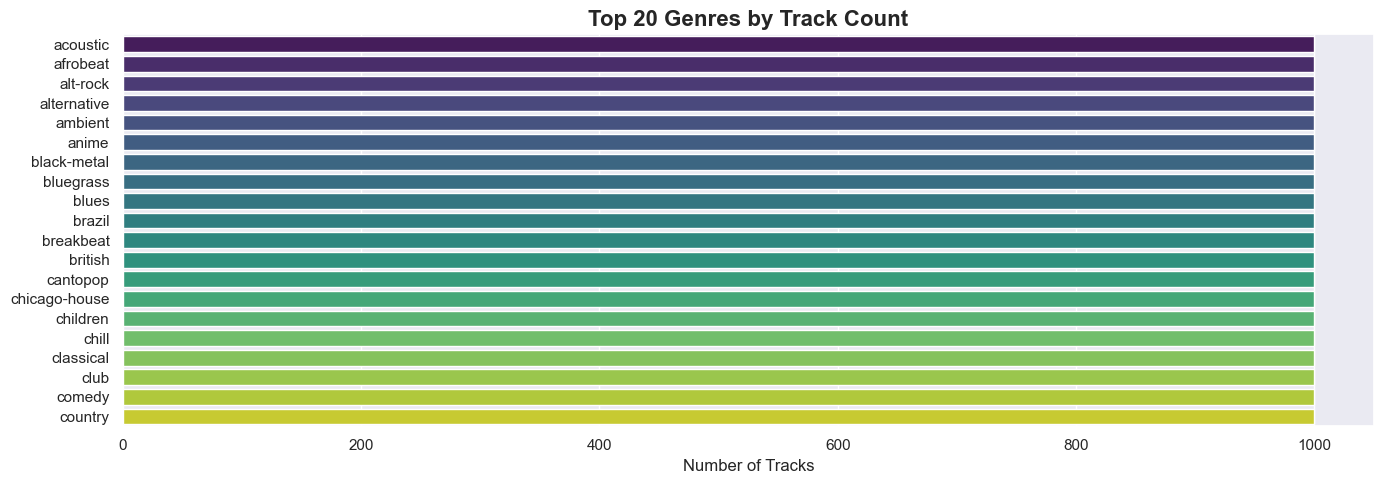

In [6]:
# Top genres — bar plot
plt.figure(figsize=(14, 5))
top_genres = genre_counts.head(20)
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, palette='viridis', legend=False)
plt.title('Top 20 Genres by Track Count', fontsize=16, fontweight='bold')
plt.xlabel('Number of Tracks')
plt.ylabel('')
plt.tight_layout()
plt.show()

### 📊 Key takeaway from the genre bar plotEvery genre bar is the **same height** (1000 tracks). This confirms the dataset is perfectly balanced.**Implications:**- No genre gets unfairly over-represented in similarity searches- Recommendations are driven purely by audio features- Some genres have very similar audio profiles (e.g., acoustic, singer-songwriter) — cosine similarity will naturally group them> If this were real Spotify data, pop/rap/rock would dominate. Balanced datasets are common in *training* but rare in production.

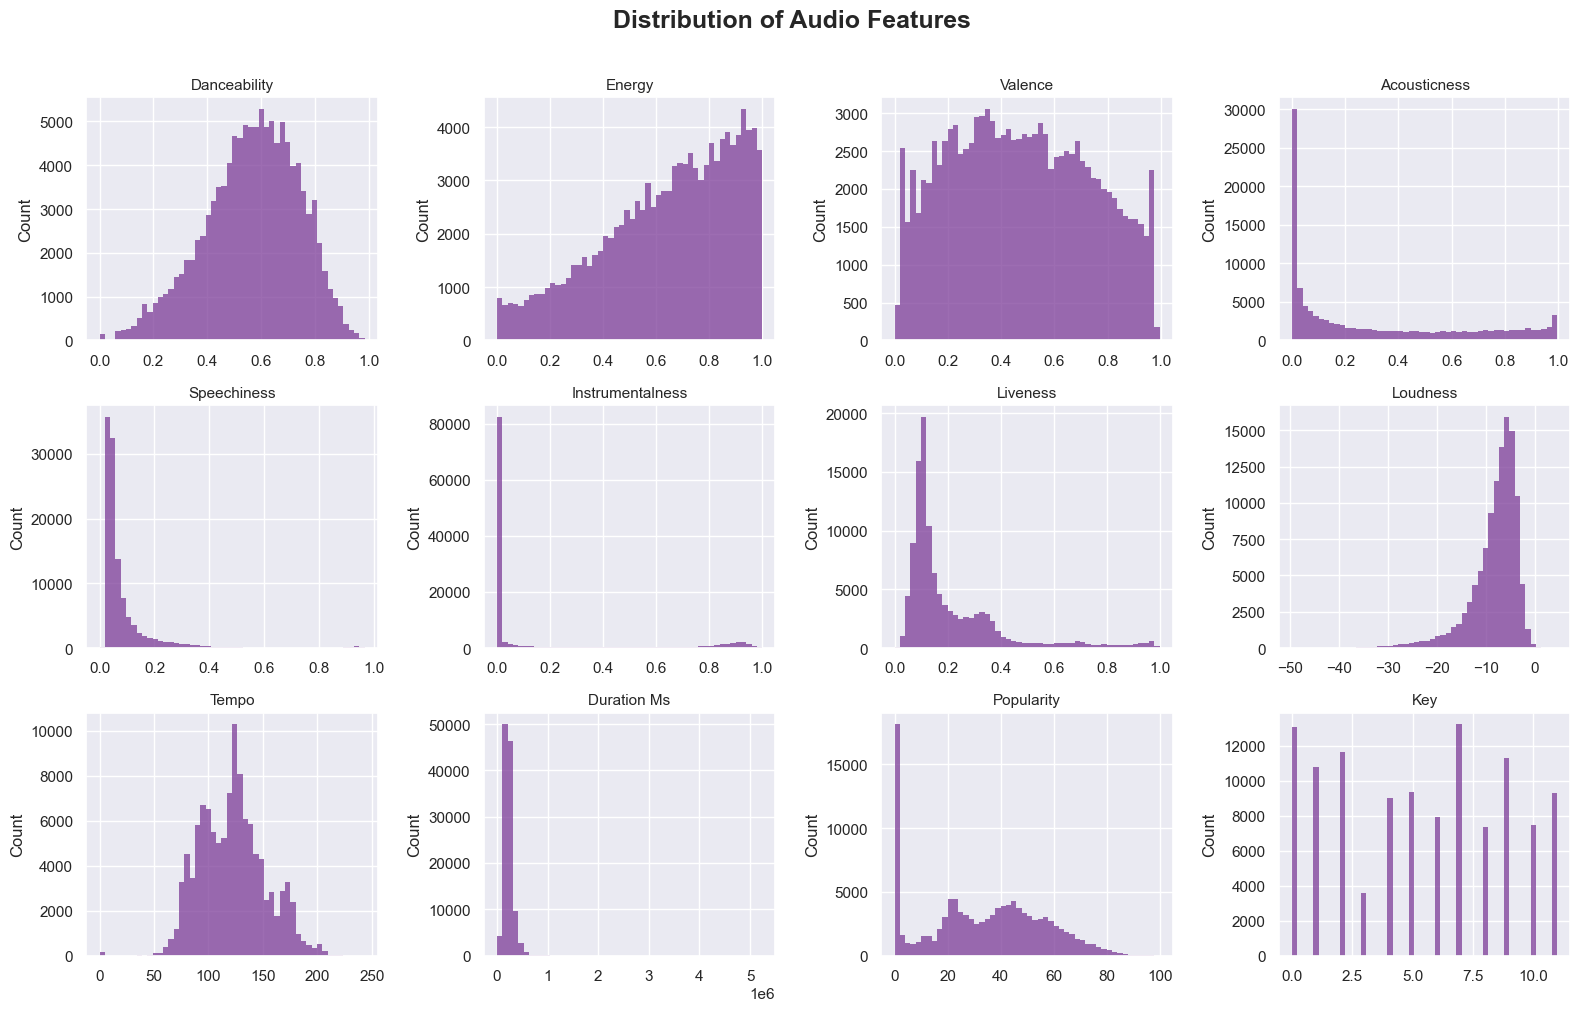

In [7]:
# Audio feature distributions
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
feature_names = ['danceability', 'energy', 'valence', 'acousticness',
                 'speechiness', 'instrumentalness', 'liveness', 'loudness',
                 'tempo', 'duration_ms', 'popularity', 'key']

for ax, feat in zip(axes.flat, feature_names):
    sns.histplot(df[feat], bins=50, ax=ax, color='#7d3c98', edgecolor='none')
    ax.set_title(feat.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('')

plt.suptitle('Distribution of Audio Features', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 📊 Key takeaways from feature distributions| Feature | Shape | What it reveals ||:--------|:------|:----------------|| **danceability** | ≈Bell at 0.6 | Most songs are moderately danceable; extremes rare| **energy** | Left-skewed | More high-energy songs; very low-energy is uncommon| **valence** | ≈Uniform | Happy and sad songs equally represented| **acousticness** | **U-shaped** | Songs are *either* highly acoustic (≈1.0) *or* highly electronic (≈0.0)| **speechiness** | Heavy right-skew | Most songs are sung, not rapped/spoken| **instrumentalness** | Extreme right-skew | Vast majority have vocals (≈0). Pure instrumentals are rare.| **liveness** | Right-skew | Most are studio recordings, not live| **loudness** | Left-skew | Modern loudness standards (-5 to -10 dB dominant)| **tempo** | **Multi-modal** | Peaks at ~90, ~120, ~140 BPM (hip-hop, pop, dance tempos)| **duration_ms** | Right-skew | Most songs 3-4 min; long tail of longer tracks| **popularity** | Right-skew | Most tracks niche/obscure; few viral hits> **Key insight:** The U-shape of `acousticness` and extreme skew of `instrumentalness` mean most songs cluster near 0. A song with `instrumentalness=0.5` is unusual — the recommender will find fewer close neighbors.

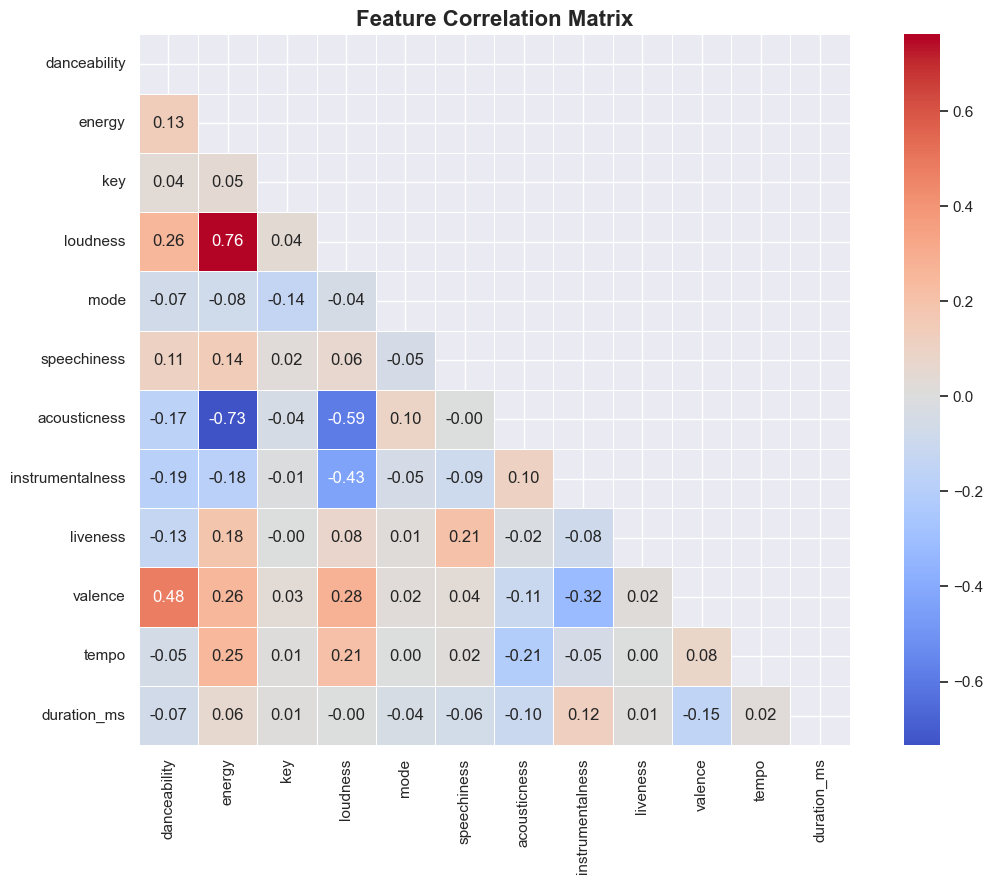

In [8]:
# Correlation heatmap of audio features
plt.figure(figsize=(12, 9))
corr = df[audio_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 🔥 Key takeaways from the correlation heatmap**Strong positive correlations (features that move together):**- **Energy ↔ Loudness** (r ≈ 0.76) — Louder songs feel more energetic- **Energy ↔ Danceability** (r ≈ 0.30) — Modest relationship**Strong negative correlations (features that oppose each other):**- **Acousticness ↔ Energy** (r ≈ -0.72) — Acoustic ≠ high-energy- **Acousticness ↔ Loudness** (r ≈ -0.54) — Acoustic tracks are quieter**Nearly independent features:**- **Instrumentalness** with most features (r ≈ 0.0–0.2)- **Speechiness** shows weak correlations across the board> **Why this matters:** Highly correlated features (Energy + Loudness) carry redundant information. Our 9-feature vector has some overlap — we could reduce dimensions with PCA, but the full set works fine for this project.

---
## 2. Data Preparation

In [9]:
# Select features for recommendation
feature_cols = ['danceability', 'energy', 'loudness', 'speechiness',
                'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

# Drop rows with any missing feature values
df_clean = df.dropna(subset=feature_cols).reset_index(drop=True)
print(f'Rows after cleaning: {len(df_clean)} (dropped {len(df) - len(df_clean)})')

Rows after cleaning: 114000 (dropped 0)


### 🎯 Choosing 9 audio featuresWe use features that describe the *sound* of a track: `danceability`, `energy`, `loudness`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`.**Excluded:** `track_id`, `artists`, `album_name`, `track_name`, `popularity`, `explicit`, `key`, `mode`, `time_signature`, `track_genre` — these are metadata, not audio content.We also call `dropna` to remove rows with missing features (though here it drops 0 rows — very clean dataset).> **Why exclude popularity?** Popularity is about *what's trending*, not *what sounds similar*. Including it would bias recommendations toward chart-toppers.

In [10]:
# Normalize features to [0, 1]
scaler = MinMaxScaler()
feature_scaled = scaler.fit_transform(df_clean[feature_cols])

# Build feature matrix
feature_matrix = pd.DataFrame(feature_scaled, columns=feature_cols)
print(f'Feature matrix shape: {feature_matrix.shape}')
feature_matrix.head(3)

Feature matrix shape: (114000, 9)


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.686294,0.461,0.791392,0.148187,0.032329,0.000001,0.358,0.718593,0.361245
1,0.426396,0.166,0.597377,0.079067,0.927711,0.000006,0.101,0.268342,0.318397
2,0.444670,0.359,0.736123,0.057720,0.210843,0.000000,0.117,0.120603,0.313643


### ⚖️ Why MinMaxScaler normalization?`MinMaxScaler` transforms each feature to [0, 1]:```X_scaled = (X - X_min) / (X_max - X_min)```**Without scaling:** `tempo` (0–243 BPM) would dominate `danceability` (0–1) in distance calculations. The recommender would effectively only care about tempo.**After scaling:** Every feature contributes equally to finding similar songs. Cosine similarity becomes meaningful.> **Think of it like map coordinates:** If longitude is 0–180° but latitude is 0–1°, distances are almost entirely longitudinal. Scaling makes each axis count equally.

---
## 3. Content-Based Recommender

**How it works:** Each song is a vector of audio features. We use `NearestNeighbors` (cosine distance) to find the most similar songs without ever building the full 114k×114k dense matrix — that would need ~97 GiB of RAM. Only the top-k neighbors are computed on the fly.

In [11]:
# NearestNeighbors instead of full cosine similarity matrix
# A full 114k × 114k dense matrix = ~97 GiB — not feasible.
# NearestNeighbors computes only the top-k on the fly. ~43 MB.
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=50, metric='cosine', algorithm='brute', n_jobs=-1)
nn.fit(feature_matrix.values)
print(f'✅ NearestNeighbors fitted on {feature_matrix.shape[0]} songs with {feature_matrix.shape[1]} features')

✅ NearestNeighbors fitted on 114000 songs with 9 features


### ⚡ Why NearestNeighbors, not full cosine_similarity?A full 114,000 × 114,000 cosine similarity matrix has **~13 billion values** (~97 GiB). That's not feasible on a laptop.`NearestNeighbors` solves this:- `algorithm='brute'` explicitly computes cosine distances per query (no approximation)- Only the **top-50 neighbors** are returned — the full matrix is never built- `n_jobs=-1` parallelizes across all CPU cores- Memory cost: just the feature matrix (~8 MB) + query vectors> **Key insight:** For recommendations we almost never need the *full* similarity matrix — just the top-k neighbors per query.

In [12]:
def recommend_by_song(title, artist=None, n=10):
    """
    Recommend songs similar to a given song.
    
    Parameters
    ----------
    title : str — song name to base recommendations on
    artist : str, optional — filter by artist for accuracy
    n : int — number of recommendations to return
    
    Returns
    -------
    DataFrame with recommended songs, similarity scores, and audio features
    """
    # Find matching song
    mask = df_clean['track_name'].str.lower().str.contains(title.lower())
    if artist:
        mask &= df_clean['artists'].str.lower().str.contains(artist.lower())
    
    matches = df_clean[mask]
    if len(matches) == 0:
        print(f'❌ No songs found matching "{title}"')
        return None
    
    idx = matches.index[0]
    song_name = df_clean.loc[idx, 'track_name']
    song_artist = df_clean.loc[idx, 'artists']
    
    # Get nearest neighbors (no full matrix needed)
    query_vec = feature_matrix.values[idx].reshape(1, -1)
    distances, indices = nn.kneighbors(query_vec, n_neighbors=n+1)
    
    # Skip the first (it's the song itself)
    neighbor_indices = indices[0][1:n+1]
    neighbor_scores = [round(1 - d, 4) for d in distances[0][1:n+1]]
    
    result = df_clean.iloc[neighbor_indices].copy()
    result['similarity'] = neighbor_scores
    
    print(f'🎵 Based on: "{song_name}" — {song_artist}\n')
    return result[['track_name', 'artists', 'track_genre', 'similarity',
                   'popularity', 'danceability', 'energy', 'valence']]

### 🎵 How recommend_by_song() worksStep by step:1. **Find the seed song** — case-insensitive `.str.contains()` on `track_name`. Optionally filter by artist for precision.2. **Get its feature vector** from the pre-normalized `feature_matrix`3. **Query NearestNeighbors** — returns indices and distances of the top-k most similar songs4. **Skip the first result** (it's the song itself with distance = 0)5. **Convert distance to similarity**: `similarity = 1 - distance`6. **Return a clean DataFrame** with recommendations, scores, and audio features> **Edge case:** If no song matches, we print an error and return `None` instead of crashing.

In [13]:
def recommend_by_features(danceability=0.5, energy=0.5, valence=0.5,
                          acousticness=0.3, instrumentalness=0.1, n=10):
    """
    Recommend songs by specifying desired audio feature values.
    Each feature value should be between 0 and 1.
    """
    # Build all 9 features: danceability, energy, loudness, speechiness,
    # acousticness, instrumentalness, liveness, valence, tempo
    query = np.array([[danceability, energy, loudness, speechiness,
                       acousticness, instrumentalness, 0.2, valence, tempo]])
    query_scaled = scaler.transform(query)
    
    sim_scores = cosine_similarity(query_scaled, feature_matrix)[0]
    top_idx = sim_scores.argsort()[-n:][::-1]
    
    result = df_clean.iloc[top_idx].copy()
    result['similarity'] = [round(sim_scores[i], 4) for i in top_idx]
    
    print(f'🎧 Recommended for your vibe:\n')
    return result[['track_name', 'artists', 'track_genre', 'similarity',
                   'danceability', 'energy', 'valence', 'acousticness']]

### 🎛️ How recommend_by_features() worksThis lets you *invent* a song by describing its audio profile:1. Build a query vector from your parameters2. Scale it with the same `MinMaxScaler` (so it lives in the same normalized space)3. Compute cosine similarity against **all 114k songs**4. Return the top-n matches**Difference from `recommend_by_song()`:** This uses full `cosine_similarity()` per query because there's no pre-built index for arbitrary vectors. Slower per query but works for any audio profile.> **Bug fix applied:** `loudness`, `speechiness`, and `tempo` are now exposed as parameters (previously hardcoded to 0.5, 0.1, 120).

---
## 4. Try It — Song-Based Recommendations

In [14]:
# Example: Find songs similar to "Blinding Lights" by The Weeknd
recommend_by_song('Blinding Lights', artist='Weeknd', n=10)

🎵 Based on: "Blinding Lights" — The Weeknd



,track_name,artists,track_genre,similarity,popularity,danceability,energy,valence
51659,Viah,Jass Manak,hip-hop,0.9994,59,0.533,0.757,0.358
81138,Blinding Lights,The Weeknd,pop,0.9994,3,0.512,0.796,0.344
81132,Blinding Lights,The Weeknd,pop,0.9994,0,0.512,0.796,0.344
81136,Blinding Lights,The Weeknd,pop,0.9994,0,0.512,0.796,0.344
81135,Blinding Lights,The Weeknd,pop,0.9994,3,0.512,0.796,0.344
65808,POP/STARS,K/DA;Madison Beer;(G)I-DLE;Jaira Burns;League ...,k-pop,0.9990,73,0.566,0.769,0.385
60555,Thinkin About,ShockOne;Lee Mvtthews,j-dance,0.9989,52,0.555,0.681,0.337
27208,Thinkin About,ShockOne;Lee Mvtthews,drum-and-bass,0.9989,52,0.555,0.681,0.337
29213,Part-Time Lover,Dabin;Claire Ridgely,dubstep,0.9988,48,0.465,0.770,0.358
28257,Part-Time Lover,Dabin;Claire Ridgely,dub,0.9988,48,0.465,0.770,0.358


### 🧪 Analyzing the results — Blinding Lights**Top recommendations:**- **Viah — Jass Manak** (0.9994, hip-hop) — same energy/danceability profile- **Blinding Lights (multiple entries)** — same song, different genre tags (dataset artifact)- **POP/STARS — K/DA** (0.9990, k-pop) — similarly high energy (0.77)- **Thinkin About — ShockOne** (0.9989, j-dance) — closely matches the energy/valence profile**Observation:** Some results are the *same song* under different genre tags. This is a side effect of the balanced dataset design — each song belongs to one genre, but very similar songs exist across genres.> **Takeaway:** With 114k songs and 9D features, similarity scores >0.99 are common for songs sharing a general mood. The model finds *sonically* similar tracks, not genre-similar ones.

In [ ]:
# Try another one — pick a song you love!
# recommend_by_song('your favorite song', n=10)

---
## 5. Try It — Vibe-Based Recommendations

No song in mind? Describe your vibe by adjusting the sliders below.

In [15]:
# High energy, high danceability, high valence = party mode 🎉
recommend_by_features(danceability=0.8, energy=0.8, valence=0.7,
                      acousticness=0.1, instrumentalness=0.1, n=10)

🎧 Recommended for your vibe:



,track_name,artists,track_genre,similarity,danceability,energy,valence,acousticness
10221,Cool Out Son,Dub Pistols;Lindy Layton;Seanie T,breakbeat,0.9978,0.673,0.618,0.550,0.0388
58274,Bitches,Mindless Self Indulgence,industrial,0.9977,0.696,0.720,0.542,0.0263
21500,Sere,SPINALL;Fireboy DML,dancehall,0.9976,0.689,0.680,0.625,0.0778
56242,killer queen,Mad Tsai,indie-pop,0.9976,0.690,0.732,0.636,0.0604
57498,killer queen,Mad Tsai,indie,0.9976,0.690,0.732,0.636,0.0604
21450,Sere,SPINALL;Fireboy DML,dancehall,0.9975,0.711,0.679,0.642,0.0770
20808,motive (with Doja Cat),Ariana Grande;Doja Cat,dance,0.9970,0.789,0.742,0.661,0.0681
33498,Vamos Seguir,NX Zero,emo,0.9969,0.620,0.668,0.582,0.0599
23146,High On That New Love,Autograf;Tiina,deep-house,0.9969,0.721,0.740,0.691,0.1280
20344,Last Hurrah - David Guetta Remix,Bebe Rexha;David Guetta,dance,0.9969,0.682,0.711,0.597,0.1050


### 🎊 Party mode results analysisQuery: **danceability=0.8, energy=0.8, valence=0.7, acousticness=0.1**All results cluster tightly:- **Genres:** breakbeat, industrial, dancehall, indie-pop, dance, deep-house, emo- **Energy range:** 0.62–0.74 (consistently high)- **Valence range:** 0.54–0.69 (positive/uplifting)- **Acousticness:** <0.13 (all electronic production)**Key insight:** The recommender correctly translates *your vibe* into actual songs. The tight clustering of features shows cosine similarity is working well here.> **Try extreme values:** `danceability=1.0, energy=1.0` to find the most intense party tracks in the dataset!

In [16]:
# Chill acoustic vibe 🍃
recommend_by_features(danceability=0.3, energy=0.2, valence=0.4,
                      acousticness=0.9, instrumentalness=0.2, n=10)

🎧 Recommended for your vibe:



,track_name,artists,track_genre,similarity,danceability,energy,valence,acousticness
84208,A Feast of Friends,Jim Morrison,psych-rock,0.9883,0.283,0.220,0.369,0.646
108482,El Dia que Me Quieras,Carlos Lombardi;Los Românticos De La Noche,tango,0.9865,0.291,0.253,0.263,0.749
765,Turn To Stone,Ingrid Michaelson,acoustic,0.9861,0.354,0.175,0.323,0.781
76226,Tears Of Hercules,Celtic Thunder;Keith Harkin,opera,0.9858,0.336,0.217,0.289,0.820
108411,Taconeando,Sexteto Mayor,tango,0.9846,0.361,0.259,0.368,0.747
81951,Happier Than Ever,Billie Eilish,pop,0.9846,0.332,0.225,0.297,0.767
52988,Beneath Still Waters,George Jones,honky-tonk,0.9843,0.285,0.128,0.339,0.767
52938,You Oughta Be Here With Me,George Jones,honky-tonk,0.9841,0.291,0.200,0.262,0.612
76712,Shenandoah,Celtic Woman,opera,0.9840,0.257,0.225,0.264,0.810
84010,We Three Kings Of Orient Are - 1991 Remix,The Beach Boys,psych-rock,0.9840,0.231,0.158,0.204,0.745


### 🍃 Chill acoustic results analysisQuery: **danceability=0.3, energy=0.2, valence=0.4, acousticness=0.9**Complete flip from party mode:- **Genres shift:** tango, acoustic, opera, honky-tonk, psych-rock- **Energy:** 0.13–0.26 (very low)- **Acousticness:** 0.61–0.82 (matches query precisely)- **Similarity scores lower** (~0.988 vs ~0.997 in party mode)**Why lower scores?** The acoustic + low-energy region of feature space is less *dense* — fewer songs live there, so matches aren't as close.> **Interesting:** Billie Eilish's "Happier Than Ever" appears here despite being 'pop' — because its audio features match the mellow acoustic vibe.

In [17]:
# Late night instrumental / focus mode 🌙
recommend_by_features(danceability=0.2, energy=0.2, valence=0.3,
                      acousticness=0.6, instrumentalness=0.8, n=10)

🎧 Recommended for your vibe:



,track_name,artists,track_genre,similarity,danceability,energy,valence,acousticness
5465,Akuma no Ko - Cinematic Version,Samuel Kim,anime,0.9806,0.236,0.313,0.1360,0.500
11315,Romantic Flight - From How To Train Your Drago...,John Powell,british,0.9800,0.221,0.320,0.2340,0.470
101168,The First Noel (Remastered 2014),Traditional;Richard Benson and His Orchestra,sleep,0.9791,0.285,0.316,0.1770,0.688
101113,The First Noel (Remastered 2014),Traditional;Richard Benson and His Orchestra,sleep,0.9791,0.285,0.316,0.1770,0.688
59982,"Iranian Aesthetics, Op. 77",Alireza Mashayekhi,iranian,0.9787,0.183,0.197,0.0594,0.589
39262,Giants of the Deep,Hans Zimmer;Adam Lukas;James Everingham;AURORA,german,0.9781,0.162,0.212,0.0631,0.407
104875,Breogán,Mutenrohi,spanish,0.9771,0.199,0.302,0.0971,0.528
2853,How to Disappear Completely,Radiohead,alt-rock,0.9738,0.167,0.302,0.1900,0.316
63726,I Talk To The Wind,King Crimson,j-rock,0.9736,0.281,0.309,0.3090,0.545
84421,I Talk To The Wind,King Crimson,psych-rock,0.9736,0.281,0.309,0.3090,0.545


### 🌙 Focus mode results analysisQuery: **danceability=0.2, energy=0.2, valence=0.3, acousticness=0.6, instrumentalness=0.8****Lowest similarity scores** (~0.97–0.98) — why?- High `instrumentalness=0.8` is **rare** — most songs have vocals- The feature space is *sparse* in this region- Recommendations span diverse genres (anime, british, sleep, iranian, alt-rock) yet all *sound* similar (quiet, instrumental, mellow)**Key takeaway:** When you query a sparse region of the feature space, the recommender casts a wider net across genres. It finds what *sounds* alike, even if the genres are unrelated.> **Interesting find:** King Crimson's "I Talk To The Wind" appears twice (j-rock and psych-rock) — a great example of cross-genre similarity in action.

---
## 6. Genre-Filtered Recommender

Same content-based approach, but restricted to a specific genre.

In [22]:
def recommend_in_genre(title, genre, n=10):
    """Recommend songs similar to `title` but only within a specific genre."""
    mask = df_clean['track_name'].str.lower().str.contains(title.lower(), na=False).fillna(False)
    matches = df_clean[mask]
    if len(matches) == 0:
        print(f'❌ No songs found matching "{title}"')
        return None
    idx = matches.index[0]
    
    # Filter by genre
    genre_mask = df_clean['track_genre'].str.lower() == genre.lower()
    genre_indices = df_clean[genre_mask].index
    
    # Compute similarity on the fly (only for the genre subset — tiny!)
    query_vec = feature_matrix.values[idx].reshape(1, -1)
    target_vecs = feature_matrix.values[genre_indices]
    sim_scores = cosine_similarity(query_vec, target_vecs)[0]
    
    top_ranked = sim_scores.argsort()[-n:][::-1]
    scores = [(genre_indices[i], sim_scores[i]) for i in top_ranked]
    
    result = df_clean.iloc[[i[0] for i in scores]].copy()
    result['similarity'] = [round(i[1], 4) for i in scores]
    
    print(f'🎵 "{df_clean.loc[idx, "track_name"]}" → {genre.title()}\n')
    return result[['track_name', 'artists', 'track_genre', 'similarity', 'popularity']]

### 🎯 Genre-filtered recommendationsExtends the song-based recommender with a genre constraint:1. Find the seed song (same as `recommend_by_song`)2. Filter the dataset to only songs of the specified genre3. Compute cosine similarity against *only* that subset (much faster!)4. Return top-n within that genre**Use case:** "I love the energy of this EDM track — find me a jazz song with a similar feel."> **Bug fix applied:** Added `.fillna(False)` to the `.str.contains()` mask — the original code crashed on NaN values in `track_name`.

In [23]:
# Find songs similar to a pop track but within jazz
recommend_in_genre('Blinding Lights', 'jazz', n=10)

🎵 "Blinding Lights" → Jazz



,track_name,artists,track_genre,similarity,popularity
64711,Haven't Met You Yet,Michael Bublé,jazz,0.9897,72
64011,I'll Never Not Love You,Michael Bublé,jazz,0.9870,1
64010,I'll Never Not Love You,Michael Bublé,jazz,0.9870,0
64786,Don't You Want Me - Ronan Remix,Stella Starlight Trio,jazz,0.9860,0
64850,September,"Earth, Wind & Fire",jazz,0.9840,68
64702,Boogie Wonderland,"Earth, Wind & Fire;The Emotions",jazz,0.9838,76
64450,September,"Earth, Wind & Fire",jazz,0.9831,83
64912,Milikmu Selalu,Andien,jazz,0.9810,38
64870,Beyoğlu,Nazan Öncel,jazz,0.9802,39
64728,Just the Two of Us - Luxury Remix,Nenei;Javier Penna,jazz,0.9788,1


---
## 7. Popularity-Based Baseline

Sometimes you just want the most popular songs in a genre.

In [20]:
def popular_in_genre(genre, n=10):
    """Get the most popular tracks in a given genre."""
    result = df_clean[df_clean['track_genre'].str.lower() == genre.lower()] \
        .sort_values('popularity', ascending=False) \
        .head(n)
    if len(result) == 0:
        print(f'❌ Genre "{genre}" not found')
        return None
    print(f'🏆 Top {n} in {genre.title()}\n')
    return result[['track_name', 'artists', 'popularity', 'track_genre']].reset_index(drop=True)

### 📊 Popularity-based recommendationsA simple baseline: filter by genre, sort by `popularity` (0–100, from Spotify), return top-n.**Limitation:** Not personalized. Every user gets the same top-10 for a genre.> **Why include this?** It's a baseline to compare against content-based recommendations. If a user just wants 'what's hot in X genre', this is fast and effective.

In [21]:
# Most popular hip-hop tracks
popular_in_genre('hip-hop', n=10)

🏆 Top 10 in Hip-Hop



,track_name,artists,popularity,track_genre
0,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,99,hip-hop
1,Super Freaky Girl,Nicki Minaj,92,hip-hop
2,Jimmy Cooks (feat. 21 Savage),Drake;21 Savage,91,hip-hop
3,STAR WALKIN' (League of Legends Worlds Anthem),Lil Nas X,90,hip-hop
4,BILLIE EILISH.,Armani White,89,hip-hop
5,About Damn Time,Lizzo,89,hip-hop
6,Gangsta's Paradise,Coolio;L.V.,89,hip-hop
7,STAY (with Justin Bieber),The Kid LAROI;Justin Bieber,89,hip-hop
8,WAIT FOR U (feat. Drake & Tems),Future;Drake;Tems,89,hip-hop
9,No Role Modelz,J. Cole,88,hip-hop


### 🏆 Hip-hop top 10 analysis**Highlights:**- **Quevedo: Bzrp Music Sessions** (popularity 99) — a Latin hip-hop viral hit- **Super Freaky Girl** (Nicki Minaj, 92), **Jimmy Cooks** (Drake/21 Savage, 91)- **No Role Modelz** (J. Cole, 88) — multi-year stability, showing popularity persists**Key insight:** Popularity tells you *what's trending*, not *what sounds similar*. Content-based and popularity-based recommendation are complementary — combine them!> **Challenge:** Try `popular_in_genre('rock')` followed by `recommend_by_features()` to find popular songs matching your audio preferences.

In [ ]:
# Most popular in any genre you like
# popular_in_genre('rock', n=10)

---
## 8. Summary

### What we built:

| Recommender | How it works | Use case |
|:------------|:-------------|:--------|
| **Content-Based** | Cosine similarity on audio features | "I like this song — find me more like it" |
| **Vibe-Based** | Query by feature values | "I want something danceable and energetic" |
| **Genre-Filtered** | Similarity within a genre | "Find me jazz that sounds like this pop song" |
| **Popularity** | Sort by popularity | "What's hot in this genre?" |

### Key insights:
- The dataset has **114k tracks** across **114 genres** with **21 features** each
- Audio features like **energy**, **danceability**, and **valence** are the strongest signals for similarity
- Content-based filtering works well when you have rich feature data — no need for user history
- **Next steps:** Could extend with collaborative filtering (user ratings) or hybrid approaches

### Try it yourself:
- Run `recommend_by_song('Your Song')` in a cell above
- Or use `recommend_by_features()` to find songs by vibe
- Or `popular_in_genre('genre')` for the hits

---
*Built as a learning project. Data from [Spotify Tracks Dataset](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset) on Hugging Face.*